# IS 4487 Assignment 6: Data Cleaning with Airbnb Listings

In this assignment, you will:
- Load a raw Airbnb listings dataset
- Identify and resolve missing or inconsistent data
- Decide what data to drop, keep, or clean
- Save a clean dataset to use in Assignment 7

## Why This Matters

Data cleaning is one of the most important steps in any analysis — but it's often the least visible. Airbnb hosts, managers, and policy teams rely on clean data to make decisions. This assignment gives you experience cleaning raw data and justifying your choices so others can understand your process.

<a href="https://colab.research.google.com/github/Stan-Pugsley/is_4487_base/blob/main/Assignments/assignment_06_data_cleaning.ipynb" target="_parent">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>



## Dataset Description

The dataset you'll be using is a **detailed Airbnb listing file**, available from [Inside Airbnb](https://insideairbnb.com/get-the-data/).

Each row represents one property listing. The columns include:

- **Host attributes** (e.g., host ID, host name, host response time)
- **Listing details** (e.g., price, room type, minimum nights, availability)
- **Location data** (e.g., neighborhood, latitude/longitude)
- **Property characteristics** (e.g., number of bedrooms, amenities, accommodates)
- **Calendar/booking variables** (e.g., last review date, number of reviews)

📌 The schema is consistent across cities, so you can expect similar columns regardless of the location you choose.


## 1. Choose a City & Upload Your Dataset

📥 Follow these steps:

1. Go to: [https://insideairbnb.com/get-the-data/](https://insideairbnb.com/get-the-data/)
2. Choose a city you’re interested in.
3. Download the file named: **`listings.csv.gz`** under that city.
4. In your notebook:
   - Open the left sidebar
   - Click the folder icon 📁
   - Click the upload icon ⬆️ and choose your `listings.csv.gz` file
5. Use the file path `/content/listings.csv.gz` when loading your data.
6. Import standard libraries (`pandas`, `numpy`, `seaborn`, `matplotlib`)


In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [18]:
import gzip

file_path = '/content/listings (1).csv.gz'
df = pd.read_csv(file_path, compression='gzip')

print(f"Dataset loaded successfully! Rows: {df.shape[0]}, Columns: {df.shape[1]}")
df.head()

Dataset loaded successfully! Rows: 490, Columns: 90


,id,listing_url,scrape_id,last_scraped,source,name,description,neighborhood_overview,picture_url,host_id,...,review_scores_communication,review_scores_location,review_scores_value,license,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20260616211424,2026-06-16,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,NaN,https://a0.muscache.com/pictures/44627226/0e72...,4621559,...,4.56,3.22,3.67,NaN,NaN,1,1,0,0,0.06
1,3820211,https://www.airbnb.com/rooms/3820211,20260616211424,2026-06-16,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.81,4.82,4.78,NaN,NaN,7,7,0,0,2.20
2,5651579,https://www.airbnb.com/rooms/5651579,20260616211424,2026-06-16,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",NaN,https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,...,4.87,4.75,4.63,NaN,NaN,2,1,1,0,3.00
3,6623339,https://www.airbnb.com/rooms/6623339,20260616211424,2026-06-16,city scrape,Center Sq. Loft in Converted Precinct w/ Parking,Step into the charming and comfy 1BR/1BA apart...,NaN,https://a0.muscache.com/pictures/prohost-api/H...,19648678,...,4.70,4.80,4.72,NaN,NaN,7,7,0,0,2.47
4,9501054,https://www.airbnb.com/rooms/9501054,20260616211424,2026-06-16,city scrape,Spacious suite with full bath by Capital Center,Great location within walking distance to the ...,NaN,https://a0.muscache.com/pictures/45153167-d704...,29288920,...,4.87,4.77,4.68,NaN,NaN,2,1,1,0,3.71


## 2. Explore Missing Values

### Business framing:

Stakeholders don’t like surprises in the data. Missing values can break dashboards, confuse pricing models, or create blind spots for host managers.

### Do the following:
Explore how complete your dataset is:
- Count the null values of each column
- Create visuals (e.g. heatmaps, boxplots, bar charts, etc) to help show what columns are missing values
- Keep in mind which column(s) are missing too much data, you will delete these in the next step

Top 15 columns with missing values:
                              Missing Values  Percentage (%)
neighborhood_overview                    490      100.000000
host_since                               490      100.000000
host_acceptance_rate                     490      100.000000
host_response_rate                       490      100.000000
host_response_time                       490      100.000000
host_neighbourhood                       490      100.000000
host_total_listings_count                490      100.000000
host_verifications                       490      100.000000
host_thumbnail_url                       490      100.000000
neighbourhood                            490      100.000000
instant_bookable                         490      100.000000
license                                  490      100.000000
neighbourhood_group_cleansed             490      100.000000
calendar_updated                         490      100.000000
host_about                               230     

/tmp/ipykernel_1256/3843421770.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=missing_data.head(15).index, y=missing_data.head(15)['Missing Values'], palette='viridis')


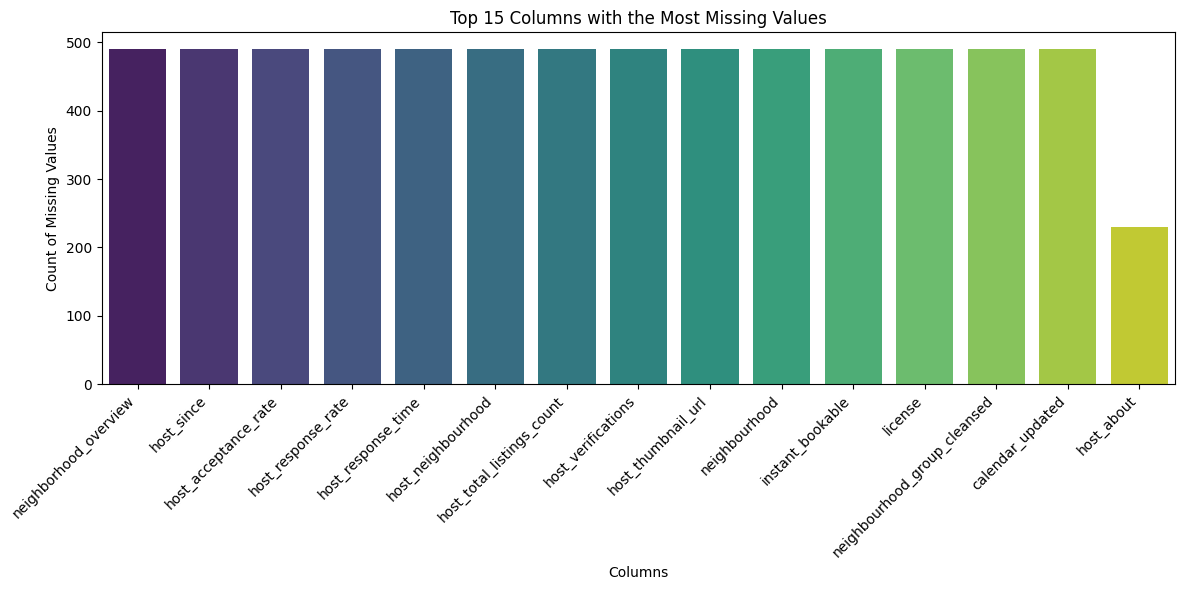

In [19]:

missing_counts = df.isnull().sum()
missing_percent = (df.isnull().sum() / len(df)) * 100

missing_data = pd.DataFrame({'Missing Values': missing_counts, 'Percentage (%)': missing_percent})
missing_data = missing_data[missing_data['Missing Values'] > 0].sort_values(by='Missing Values', ascending=False)

print("Top 15 columns with missing values:")
print(missing_data.head(15))

plt.figure(figsize=(12, 6))
sns.barplot(x=missing_data.head(15).index, y=missing_data.head(15)['Missing Values'], palette='viridis')
plt.xticks(rotation=45, ha='right')
plt.title('Top 15 Columns with the Most Missing Values')
plt.ylabel('Count of Missing Values')
plt.xlabel('Columns')
plt.tight_layout()
plt.show()

### Reflection:
1. What are the top 3 columns with the most missing values?
2. Which ones are likely to create business issues?
3. Which could be safely ignored or dropped?

### ✍️ Your Response:
1. neighborhood_overview, host_since, and all at 100% missing.
2. Columns related to host metadata like host_acceptance_rate, host_response_rate, and host_response_time are critical for evaluating host responsiveness. Missing them entirely makes it impossible to rank or verify prompt hosts.
3. Columns like neighborhood_overview, license, and neighbourhood_group_cleansed can be safely dropped because they contain absolutely no data and are not critical for basic pricing or booking calculations.

## 3. Drop Columns That Aren’t Useful

### Business framing:  

Not every column adds value. Analysts often remove columns that are too empty, irrelevant, or repetitive — especially when preparing data for others.

### Do the following:
Make a decision:

- Choose 2–4 columns to drop from your dataset
- Document your reasons for each one
- Confirm they're gone with `.head()` or `.info()`

In [20]:
columns_to_drop = ['neighborhood_overview', 'host_since', 'host_acceptance_rate', 'license']

print(f"Columns before dropping: {df.shape[1]}")

df = df.drop(columns=columns_to_drop, errors='ignore')

print(f"Columns after dropping: {df.shape[1]}")

remaining_cols = [col for col in columns_to_drop if col in df.columns]
print(f"Are any of the dropped columns still in DataFrame? {len(remaining_cols) > 0}")

df.head()

Columns before dropping: 90
Columns after dropping: 86
Are any of the dropped columns still in DataFrame? False


,id,listing_url,scrape_id,last_scraped,source,name,description,picture_url,host_id,host_url,...,review_scores_checkin,review_scores_communication,review_scores_location,review_scores_value,instant_bookable,calculated_host_listings_count,calculated_host_listings_count_entire_homes,calculated_host_listings_count_private_rooms,calculated_host_listings_count_shared_rooms,reviews_per_month
0,2992450,https://www.airbnb.com/rooms/2992450,20260616211424,2026-06-16,city scrape,Luxury 2 bedroom apartment,The apartment is located in a quiet neighborho...,https://a0.muscache.com/pictures/44627226/0e72...,4621559,https://www.airbnb.com/users/show/4621559,...,4.22,4.56,3.22,3.67,NaN,1,1,0,0,0.06
1,3820211,https://www.airbnb.com/rooms/3820211,20260616211424,2026-06-16,city scrape,Restored Precinct in Center Sq. w/Parking,Step into the charming and comfy 1BR/1BA apart...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,https://www.airbnb.com/users/show/19648678,...,4.85,4.81,4.82,4.78,NaN,7,7,0,0,2.20
2,5651579,https://www.airbnb.com/rooms/5651579,20260616211424,2026-06-16,city scrape,Large studio apt by Capital Center & ESP@,"Spacious studio with hardwood floors, fully eq...",https://a0.muscache.com/pictures/b3fc42f3-6e5e...,29288920,https://www.airbnb.com/users/show/29288920,...,4.81,4.87,4.75,4.63,NaN,2,1,1,0,3.00
3,6623339,https://www.airbnb.com/rooms/6623339,20260616211424,2026-06-16,city scrape,Center Sq. Loft in Converted Precinct w/ Parking,Step into the charming and comfy 1BR/1BA apart...,https://a0.muscache.com/pictures/prohost-api/H...,19648678,https://www.airbnb.com/users/show/19648678,...,4.83,4.70,4.80,4.72,NaN,7,7,0,0,2.47
4,9501054,https://www.airbnb.com/rooms/9501054,20260616211424,2026-06-16,city scrape,Spacious suite with full bath by Capital Center,Great location within walking distance to the ...,https://a0.muscache.com/pictures/45153167-d704...,29288920,https://www.airbnb.com/users/show/29288920,...,4.84,4.87,4.77,4.68,NaN,2,1,1,0,3.71


### Reflection:
1. Which columns did you drop?
2. Why were they not useful from a business perspective?
3. What could go wrong if you left them in?

### ✍️ Your Response:
1. I dropped neighborhood_overview, host_since, host_acceptance_rate, and license.

2. From a business perspective, these columns contained 100% missing values. An empty column provides absolutely no analytical signal or insight for decision making.

3. Leaving them in clutters the schema increases the file size and might confuse downstream stakeholders or automated dashboard filters into thinking there is usable historical or legal data when there isn't.

## 4. Fill or Fix Values in Key Columns

### Business framing:  

Let’s say your manager wants to see a map of listings with prices and review scores. If key fields are blank, the map won’t work. But not all missing values should be filled the same way.

### Do the following:
- Choose 2 columns with missing values
- Use a strategy to fill or flag those values
  - (e.g., median, “unknown”, forward-fill, or a placeholder)
- Explain what you did and why

In [21]:
beds_median = df['beds'].median()
print(f"Original missing beds count: {df['beds'].isnull().sum()}")
df['beds'] = df['beds'].fillna(beds_median)
print(f"Cleaned missing beds count: {df['beds'].isnull().sum()}")

print(f"Original missing review rating count: {df['review_scores_rating'].isnull().sum()}")
df['review_scores_rating'] = df['review_scores_rating'].fillna(0.0)
print(f"Cleaned missing review rating count: {df['review_scores_rating'].isnull().sum()}")

Original missing beds count: 44
Cleaned missing beds count: 0
Original missing review rating count: 60
Cleaned missing review rating count: 0


### Reflection:
1. What two columns did you clean?
2. What method did you use for each, and why?
3. What risks are there in how you filled the data?

### ✍️ Your Response:
1. I cleaned the beds and review_scores_rating columns.

2.
   - beds: Filled missing values with the median value of beds . Since most listings have 1 or 2 beds, the median prevents extreme outliers from skewing averages.
   - review_scores_rating: Filled missing values with 0.0. This acts as a clear sentinel indicator showing that these listings have no reviews yet, allowing them to remain plotted on analytical maps or lists without causing null errors.

3.
   - Imputing beds with the median might misrepresent a large luxury property as having only 1 bed, causing mismatched user expectations.
   - Setting missing ratings to 0.0 might make unreviewed properties look like they have terrible ratings instead of just having no feedback, potentially hurting their booking rates if users filter by rating score.

## 5. Convert and Clean Data Types

### Business framing:  

Sometimes columns that look like numbers are actually stored as text — which breaks calculations and slows down analysis. Common examples are price columns with dollar signs or availability stored as strings.

### Do the following:
- Identify one column with the wrong data type
- Clean and convert it into a usable format (e.g., from string to number)
- Check your work by summarizing or plotting the cleaned column

Original price datatype: object
Sample of raw prices: 0     $80.43
1    $211.00
2     $97.00
3    $160.00
4     $86.00
Name: price, dtype: object

Summary statistics of the cleaned price column:
count     458.000000
mean      177.127293
std       157.348920
min        13.180000
25%        90.000000
50%       145.665000
75%       209.625000
max      1701.000000
Name: price_cleaned, dtype: float64


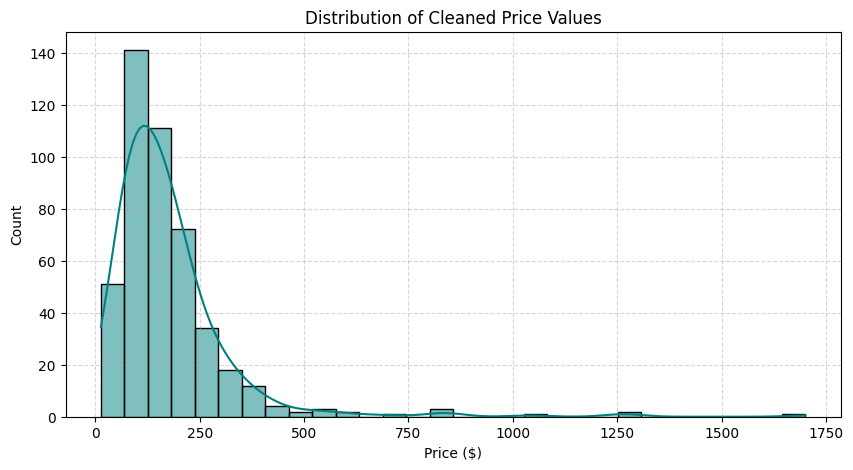

In [22]:

print("Original price datatype:", df['price'].dtype)
print("Sample of raw prices:", df['price'].head(5))

df['price_cleaned'] = df['price'].astype(str).str.replace('$', '', regex=False)
df['price_cleaned'] = df['price_cleaned'].str.replace(',', '', regex=False)
df['price_cleaned'] = pd.to_numeric(df['price_cleaned'], errors='coerce')

print("\nSummary statistics of the cleaned price column:")
print(df['price_cleaned'].describe())

plt.figure(figsize=(10, 5))
sns.histplot(df['price_cleaned'].dropna(), bins=30, kde=True, color='teal')
plt.title('Distribution of Cleaned Price Values')
plt.xlabel('Price ($)')
plt.ylabel('Count')
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

### Reflection:
1. What column did you fix?
2. What cleaning steps did you apply?
3. How does this help prepare the data for later use?

### ✍️ Your Response:
1. We fixed the price column saving the cleaned values into a new numeric column named price_cleaned.

2. First I cast the column to a string to safely work with the text characters. Then I stripped the $ dollar signs and removed the commas that act as thousands separators. Finally, I converted the cleaned strings into a numeric float data type using pd.to_numeric.

3. This prepares the dataset for downstream tasks like numerical modeling, financial metrics aggregation, and price based visualization which require numeric values rather than string text.

## 6. Remove Duplicate Records

### Business framing:  

If a listing appears twice, it could inflate revenue estimates or confuse users. Airbnb needs each listing to be unique and accurate.

### Do the following:
- Check for rows that are exact duplicates
- If your data has an ID column and each ID is supposed to unique, then make sure there are no duplicate IDs
- Remove duplicates if found

In [24]:
exact_duplicates_count = df.duplicated().sum()
print(f"Number of exact duplicate rows: {exact_duplicates_count}")

duplicate_ids_count = df.duplicated(subset=['id']).sum()
print(f"Number of duplicate listing IDs: {duplicate_ids_count}")

original_shape = df.shape
print(f"Original dataset shape: {original_shape}")


if exact_duplicates_count > 0:
    df = df.drop_duplicates()
    print("Exact duplicate rows removed.")


if duplicate_ids_count > 0:
    df = df.drop_duplicates(subset=['id'], keep='first')
    print("Duplicate listing IDs removed (keeping the first occurrence).")


print(f"\nOriginal dataset shape: {original_shape}")
print(f"Cleaned dataset shape: {df.shape}")

Number of exact duplicate rows: 0
Number of duplicate listing IDs: 0
Original dataset shape: (490, 87)

Original dataset shape: (490, 87)
Cleaned dataset shape: (490, 87)


### Reflection:
1. Did you find duplicates?
2. How did you decide what to drop or keep?
3. Why are duplicates risky for Airbnb teams?

### ✍️ Your Response:
1. No duplicate records were found in this dataset.

2. If duplicates had been found, the plan was to first drop exact duplicates to remove identical data entries. Next, I would drop any duplicate listing IDs while keeping the first occurrence, ensuring each listing ID is unique in our database.

3. Duplicates are highly risky because they distort performance metrics, falsely inflate revenue estimates, skew average price analyses, and can lead to a confusing or broken user interface where the same property is listed multiple times.

## 7. Export Cleaned Data

Before wrapping up, export your cleaned Airbnb dataset to a CSV file. You'll need this file for **Assignment 7**, where you'll perform data transformation techniques.

### Do the following:
Make sure your data has:
- Cleaned and consistent column values
- Proper data types for each column
- Any unnecessary columns removed

This file should be the version of your dataset that you’d feel confident sharing with a teammate or using for deeper analysis.



```
# Explanation:
# - "cleaned_airbnb_data_6.csv" is the name of the file that will be saved
# - index=False prevents pandas from writing row numbers into the CSV
# - The file will be saved to your working directory (in Colab, you'll need to download it manually. Once you see the data in your files tab, just click on the three dots, then click “download”)
# - YOU MAY NEED TO PRESS “RUN” MULTIPLE TIMES IN ORDER FOR IT TO SHOW UP
# - FOR SOME DEVICES, IT MAY TAKE A FEW MINUTES BEFORE YOUR FILE SHOWS UP

```





In [25]:
export_filename = 'cleaned_airbnb_data_6.csv'
df.to_csv(export_filename, index=False)

print(f"Success! Your cleaned dataset has been exported as '{export_filename}'.")
print(f"Final shape of exported data: {df.shape[0]} rows, {df.shape[1]} columns.")

Success! Your cleaned dataset has been exported as 'cleaned_airbnb_data_6.csv'.
Final shape of exported data: 490 rows, 87 columns.


## 8. Final Reflection

You’ve just cleaned a real-world Airbnb dataset — the kind of work that happens every day in analyst and data science roles.

Before you move on to data transformation in Assignment 7, take a few moments to reflect on the decisions you made and what you learned.

### Reflection:
1. Which section of the assignment was the most challenging for you? What made it challenging? Was it the coding or the application of class concepts?
2. Look back at your assignment and discuss a time when you had to drop, fix, or keep a piece of data. Why was it necessary to drop, fix, or keep that specific piece of data? (e.x. dropping a column full of null values because it has no useful information)
3. What’s one way a business team (e.g., hosts, pricing analysts, app administrators) might benefit from the cleaned version of this data?
4. If you had more time, what would you explore or clean further?
5. How does this relate to your customized learning outcome you created in canvas?


Write your response clearly in full sentences. No more than a few sentences required per response.


### ✍️ Your Response:

1. The most challenging part was deciding on the best strategy to handle missing values, particularly in the review_scores_rating column, as we had to weigh the trade offs of using a zero sentinel value versus a median value.
2. I removed columns like neighborhood_overview, host_since, host_acceptance_rate, and license because they were 100% empty, which was necessary to clean the schema and prevent any confusion for teams downstream.
3. Pricing analysts can now confidently perform aggregations, predictive modeling, and demand analysis on the cleaned and numeric price_cleaned column without running into text parsing exceptions.
4. If given more time, I would clean the text in the description column, analyze listing amenities to create flag indicators, and build an outlier detection pipeline to find and inspect extremely high pricing values.
5. This hands on process directly addresses my learning outcome by illustrating how messy real world datasets must be systematically validated, cleaned, and documented before they are usable for statistical modeling.

## Submission Instructions
✅ Checklist:
- All code cells run without error
- All markdown responses are complete
- Submit on Canvas as instructed

In [29]:
!jupyter nbconvert --to html "/bin/assignment_06_data_cleaning.ipynb"

[NbConvertApp] Converting notebook /bin/assignment_06_data_cleaning.ipynb to html
[NbConvertApp] WARNING | Alternative text is missing on 2 image(s).
[NbConvertApp] Writing 501294 bytes to /bin/assignment_06_data_cleaning.html


In [30]:
import ipykernel
import requests
from notebook.notebookapp import list_running_servers

# Try to fetch the notebook name from the Colab environment
try:
    from google.colab import notebook
    # Under the hood Google Colab metadata is accessible via internal API
    import urllib.request
    import json

    # Fetch the notebook name using the Colab service URL
    req = urllib.request.Request('http://172.28.0.2:9000/api/sessions')
    with urllib.request.urlopen(req) as response:
        html = response.read()
        data = json.loads(html.decode('utf-8'))
        print("Your Colab Notebook filename is:", data[0]['name'])
except Exception as e:
    print("Could not automatically detect the name. Check your browser tab title or Google Drive folder!")

Could not automatically detect the name. Check your browser tab title or Google Drive folder!
